# Alcaldía-Level Comparative Analysis: Demographics, Economy & Public Safety

**Author:** Gustavo Fuentes (`Audileleach`) · Phase 3 · TEAM_PLAN §4.6  
**Study Area:** All 16 Alcaldías of Mexico City (2,431 Urban AGEBs)  
**Methodology:** Strict territorial aggregation (summing numerators and denominators before ratio division)  

This notebook conducts a comparative evaluation across the **16 alcaldías** of Mexico City, contrasting central business/commercial cores against peripheral residential and conservation zones.

> **Statistical Aggregation Standard:** Correct territorial aggregation requires summing numerators and denominators across all AGEBs within each municipality before dividing with `NULLIF`, avoiding the mathematical ecological fallacy of averaging AGEB ratios.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.data import load_kpis
from src.config import OUTPUT_FIGURES

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

MUN_NAMES = {
    '002': 'Azcapotzalco', '003': 'Coyoacán', '004': 'Cuajimalpa de Morelos',
    '005': 'Gustavo A. Madero', '006': 'Iztacalco', '007': 'Iztapalapa',
    '008': 'La Magdalena Contreras', '009': 'Milpa Alta', '010': 'Álvaro Obregón',
    '011': 'Tláhuac', '012': 'Tlalpan', '013': 'Xochimilco',
    '014': 'Benito Juárez', '015': 'Cuauhtémoc', '016': 'Miguel Hidalgo',
    '017': 'Venustiano Carranza',
}

## 1. Load All Urban AGEBs & Aggregate by Alcaldía

We load all 2,431 urban AGEBs from `dw.v_kpi_ageb` and aggregate measures by municipal code (`cve_mun`).

In [2]:
kpis = load_kpis(city_core_only=False, exclude_low_population=False)
assert len(kpis) == 2431, f"Expected 2,431 urban AGEBs, got {len(kpis)}"

kpis['cve_mun'] = kpis['cvegeo'].str[2:5]
kpis['alcaldia'] = kpis['cve_mun'].map(MUN_NAMES)

# Aggregate sums
alcaldia_df = kpis.groupby('alcaldia').agg({
    'cvegeo': 'count',
    'pop_total': 'sum',
    'area_km2': 'sum',
    'businesses_total': 'sum',
    'retail_total': 'sum',
    'services_total': 'sum',
    'crime_total': 'sum',
}).rename(columns={'cvegeo': 'ageb_count'})

# Compute proper ratios
alcaldia_df['pop_density_km2'] = (alcaldia_df['pop_total'] / alcaldia_df['area_km2']).round(1)
alcaldia_df['business_density_km2'] = (alcaldia_df['businesses_total'] / alcaldia_df['area_km2']).round(1)
alcaldia_df['businesses_per_1k'] = (1000.0 * alcaldia_df['businesses_total'] / alcaldia_df['pop_total']).round(1)
alcaldia_df['retail_density_km2'] = (alcaldia_df['retail_total'] / alcaldia_df['area_km2']).round(1)
alcaldia_df['service_density_km2'] = (alcaldia_df['services_total'] / alcaldia_df['area_km2']).round(1)
alcaldia_df['crime_rate_per_1k'] = (1000.0 * alcaldia_df['crime_total'] / alcaldia_df['pop_total']).round(2)
alcaldia_df['crimes_per_100_biz'] = (100.0 * alcaldia_df['crime_total'] / alcaldia_df['businesses_total']).round(2)

# Order by recorded crime rate
alcaldia_df = alcaldia_df.sort_values('crime_rate_per_1k', ascending=False)
display(alcaldia_df)

# Save summary CSV
csv_path = OUTPUT_FIGURES / "35_alcaldia_summary.csv"
alcaldia_df.to_csv(csv_path)
print(f"Saved alcaldía comparison summary table to {csv_path}")

,ageb_count,pop_total,area_km2,businesses_total,retail_total,services_total,crime_total,pop_density_km2,business_density_km2,businesses_per_1k,retail_density_km2,service_density_km2,crime_rate_per_1k,crimes_per_100_biz
alcaldia,,,,,,,,,,,,,,
Cuauhtémoc,153,545884,32.3355,67538,34304,24988,16082,16881.9,2088.7,123.7,1060.9,772.8,29.46,23.81
Benito Juárez,102,434153,26.5490,24204,6947,14101,8627,16352.9,911.7,55.7,261.7,531.1,19.87,35.64
Miguel Hidalgo,130,414470,46.1546,25324,8203,13382,6795,8980.0,548.7,61.1,177.7,289.9,16.39,26.83
Venustiano Carranza,151,443704,33.6658,30730,16859,10561,6724,13179.7,912.8,69.3,500.8,313.7,15.15,21.88
Iztacalco,110,404695,22.9628,17405,7606,7390,5382,17623.9,758.0,43.0,331.2,321.8,13.30,30.92
Coyoacán,156,614447,53.6224,25010,9897,12473,8137,11458.8,466.4,40.7,184.6,232.6,13.24,32.53
Azcapotzalco,103,432205,33.3233,18816,7715,8201,5074,12970.1,564.6,43.5,231.5,246.1,11.74,26.97
Tlalpan,207,681501,93.2243,26039,11388,11786,7651,7310.3,279.3,38.2,122.2,126.4,11.23,29.38
La Magdalena Contreras,52,246428,18.1423,8448,3943,3669,2460,13583.1,465.7,34.3,217.3,202.2,9.98,29.12


Saved alcaldía comparison summary table to /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/figures/35_alcaldia_summary.csv


## 2. Center vs. Periphery Structural Contrast

We segment the 16 alcaldías into:
- **Central Core:** Cuauhtémoc, Benito Juárez, Miguel Hidalgo (commercial intensity, historic center, major transit hubs)
- **East / Industrial & Residential Periphery:** Iztapalapa, Gustavo A. Madero, Venustiano Carranza, Iztacalco
- **South / Semi-Rural & Conservation Periphery:** Tlalpan, Xochimilco, Milpa Alta, Tláhuac, Magdalena Contreras

In [3]:
center = ['Cuauhtémoc', 'Benito Juárez', 'Miguel Hidalgo']
east_peri = ['Iztapalapa', 'Gustavo A. Madero', 'Venustiano Carranza', 'Iztacalco', 'Azcapotzalco']
south_peri = ['Tlalpan', 'Xochimilco', 'Milpa Alta', 'Tláhuac', 'La Magdalena Contreras', 'Álvaro Obregón', 'Cuajimalpa de Morelos', 'Coyoacán']

def zone(name):
    if name in center: return 'Central Core'
    if name in east_peri: return 'East Periphery'
    return 'South / West Periphery'

kpis['zone'] = kpis['alcaldia'].map(zone)
zone_summary = kpis.groupby('zone').agg({
    'pop_total': 'sum',
    'area_km2': 'sum',
    'businesses_total': 'sum',
    'crime_total': 'sum',
})
zone_summary['pop_density_km2'] = (zone_summary['pop_total'] / zone_summary['area_km2']).round(1)
zone_summary['business_density_km2'] = (zone_summary['businesses_total'] / zone_summary['area_km2']).round(1)
zone_summary['biz_per_1k'] = (1000.0 * zone_summary['businesses_total'] / zone_summary['pop_total']).round(1)
zone_summary['crime_rate_per_1k'] = (1000.0 * zone_summary['crime_total'] / zone_summary['pop_total']).round(2)
zone_summary['crimes_per_100_biz'] = (100.0 * zone_summary['crime_total'] / zone_summary['businesses_total']).round(2)
display(zone_summary)

,pop_total,area_km2,businesses_total,crime_total,pop_density_km2,business_density_km2,biz_per_1k,crime_rate_per_1k,crimes_per_100_biz
zone,,,,,,,,,
Central Core,1394507,105.0391,117066,31504,13276.1,1114.5,83.9,22.59,26.91
East Periphery,4289441,289.7667,206453,44203,14803.1,712.5,48.1,10.31,21.41
South / West Periphery,3454576,397.3404,137712,36578,8694.2,346.6,39.9,10.59,26.56


## 3. Comparative Visual Profiles (Small Multiples)

We generate a structured 4-panel figure comparing the 16 alcaldías across Population Density, Business Density, Crime Rate, and Crime per 100 Businesses.

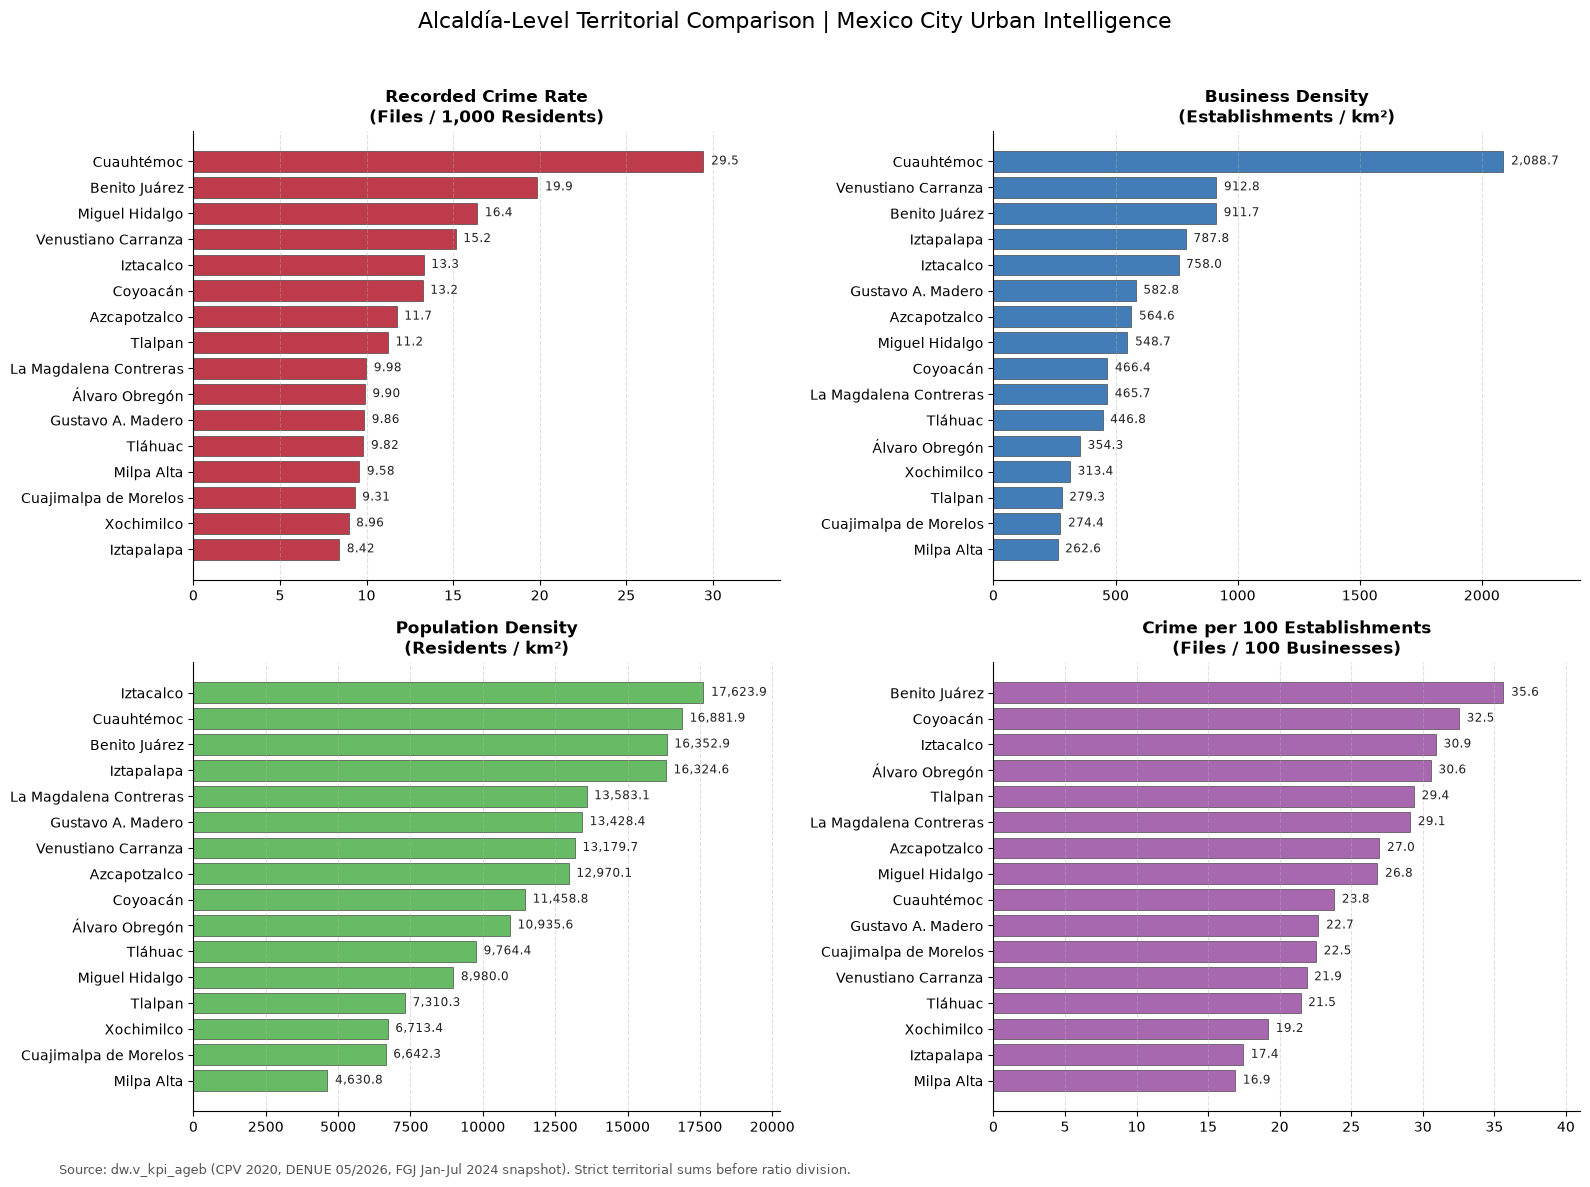

Saved comparative alcaldía figure to /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/figures/35_alcaldia_comparison.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('crime_rate_per_1k', 'Recorded Crime Rate\n(Files / 1,000 Residents)', '#b2182b'),
    ('business_density_km2', 'Business Density\n(Establishments / km²)', '#2166ac'),
    ('pop_density_km2', 'Population Density\n(Residents / km²)', '#4daf4a'),
    ('crimes_per_100_biz', 'Crime per 100 Establishments\n(Files / 100 Businesses)', '#984ea3')
]

for ax, (metric, label, color) in zip(axes.flatten(), metrics):
    sorted_df = alcaldia_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df[metric], color=color, alpha=0.85, edgecolor='#333', linewidth=0.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Value labels
    max_val = sorted_df[metric].max()
    for bar in bars:
        val = bar.get_width()
        ax.text(val + max_val * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{val:,.1f}" if val >= 10 else f"{val:,.2f}",
                va='center', fontsize=8.5, color='#222')
    ax.set_xlim(0, max_val * 1.15)

fig.suptitle("Alcaldía-Level Territorial Comparison | Mexico City Urban Intelligence", fontsize=16, y=0.98)
fig.text(0.04, 0.01, "Source: dw.v_kpi_ageb (CPV 2020, DENUE 05/2026, FGJ Jan-Jul 2024 snapshot). Strict territorial sums before ratio division.", fontsize=9, color='#555')
plt.tight_layout(rect=(0, 0.03, 1, 0.96))

fig_path = OUTPUT_FIGURES / "35_alcaldia_comparison.png"
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved comparative alcaldía figure to {fig_path}")